<a href="https://colab.research.google.com/github/NgoHoangNhatMinh/cs3264-project/blob/main/Minh/notebooks/colab_scam_guard_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Util

In [ ]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Thu Apr  9 07:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data preprocessing

In [ ]:
from datasets import load_dataset

def load_scam_data():
    print("Downloading/Loading SMS Spam dataset...")
    # This automatically fetches the dataset from Hugging Face
    dataset = load_dataset("sms_spam")

    # The dataset comes pre-split into a 'train' set.
    # Let's look at the structure of the first message:
    print("\nSample Data Structure:")
    print(dataset['train'][0])

    return dataset

dataset = load_scam_data()

Downloading/Loading SMS Spam dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]


Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}


### Tokenize and build vocabulary

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    # This handles truncation and padding automatically
    return tokenizer(examples["sms"], truncation=True, padding="max_length", max_length=128)

# Map the tokenizer over your existing Hugging Face dataset
tokenized_sms = dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5574 [00:00<?, ? examples/s]

In [ ]:
print(tokenized_sms["train"].features)

{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## Core model

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2 # Ham vs Scam
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [ ]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5, # Transformers need very small learning rates
    per_device_train_batch_size=16,
    num_train_epochs=3, # Transformers converge very fast
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

split_datasets = tokenized_sms["train"].train_test_split(test_size=0.2, seed=42)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=split_datasets["train"],
    eval_dataset=split_datasets["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.044949,0.989238
2,0.056150,0.050421,0.990135
3,0.056150,0.047732,0.992825


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=837, training_loss=0.03752388207858324, metrics={'train_runtime': 181.0517, 'train_samples_per_second': 73.885, 'train_steps_per_second': 4.623, 'total_flos': 443004097955328.0, 'train_loss': 0.03752388207858324, 'epoch': 3.0})

## Evaluation

In [ ]:
for log in trainer.state.log_history:
    print(log)

metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.04494865611195564, 'eval_accuracy': 0.989237668161435, 'eval_runtime': 3.8418, 'eval_samples_per_second': 290.23, 'eval_steps_per_second': 36.441, 'epoch': 1.0, 'step': 279}
{'loss': 0.05615039825439453, 'grad_norm': 0.06722531467676163, 'learning_rate': 8.07646356033453e-06, 'epoch': 1.7921146953405018, 'step': 500}
{'eval_loss': 0.05042089894413948, 'eval_accuracy': 0.9901345291479821, 'eval_runtime': 4.1092, 'eval_samples_per_second': 271.34, 'eval_steps_per_second': 34.07, 'epoch': 2.0, 'step': 558}
{'eval_loss': 0.047732096165418625, 'eval_accuracy': 0.9928251121076234, 'eval_runtime': 4.2745, 'eval_samples_per_second': 260.846, 'eval_steps_per_second': 32.752, 'epoch': 3.0, 'step': 837}
{'train_runtime': 181.0517, 'train_samples_per_second': 73.885, 'train_steps_per_second': 4.623, 'total_flos': 443004097955328.0, 'train_loss': 0.03752388207858324, 'epoch': 3.0, 'step': 837}


{'eval_loss': 0.044952016323804855, 'eval_accuracy': 0.989237668161435, 'eval_runtime': 4.1454, 'eval_samples_per_second': 268.972, 'eval_steps_per_second': 33.772, 'epoch': 3.0}


## Statistics Visualization

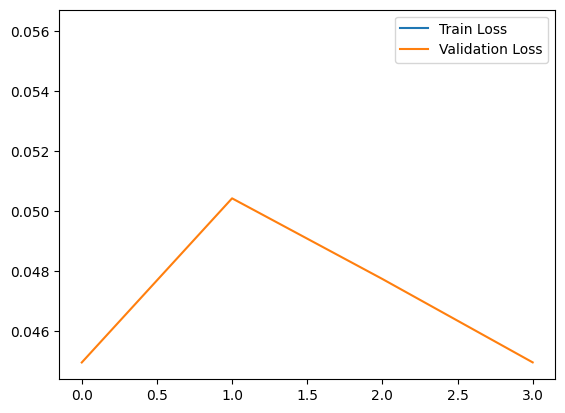

In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.show()